--- 1-Adımlık TD Avantajı ile Eğitim (GAE Kapalı) ---

--- GAE Avantajı ile Eğitim (GAE Açık) ---


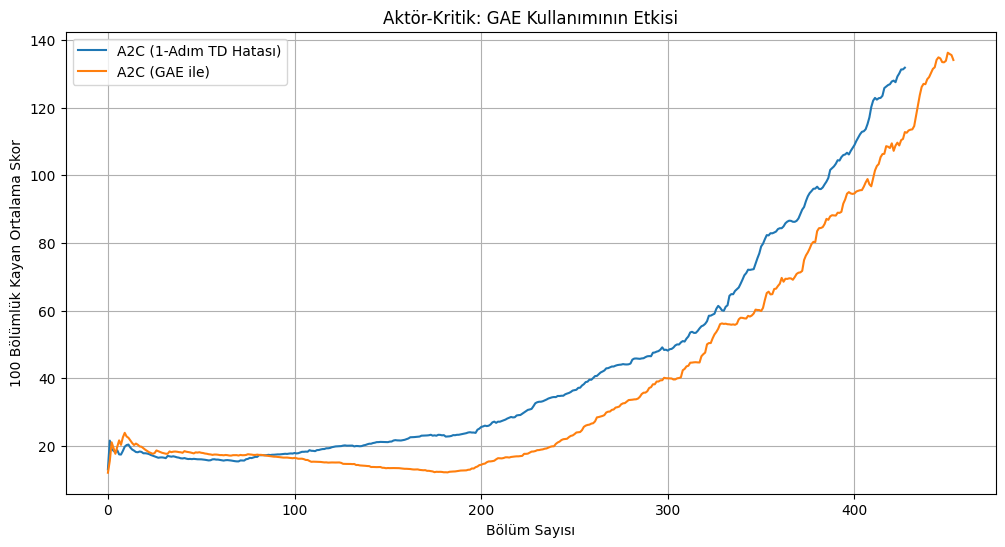

In [1]:
import gymnasium as gym
import torch
import numpy as np
import random
import os
import sys
from collections import deque
import matplotlib.pyplot as plt

# --- Proje Kök Dizinini Python Path'e Ekleme ---
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# --- Ajan Modülümüzü İçe Aktarma ---
from src.agents.a2c_minimal import A2CAgent

# --- Kurulum ve Seed Ayarları ---
def set_seed(seed_value=42):
    torch.manual_seed(seed_value)
    np.random.seed(seed_value)
    random.seed(seed_value)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# --- Genel Eğitim Fonksiyonu ---
def train(agent, env, use_gae, total_timesteps=25000, n_steps=5):
    scores_deque = deque(maxlen=100)
    avg_scores = []
    timestep_idx = 0
    
    state, _ = env.reset()
    current_episode_reward = 0

    while timestep_idx < total_timesteps:
        states_list, actions_list, log_probs, values, rewards, dones = [], [], [], [], [], []
        
        for _ in range(n_steps):
            timestep_idx += 1
            states_list.append(state)
            
            action, log_prob, value = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            actions_list.append(torch.tensor([action], device=device))
            log_probs.append(log_prob)
            values.append(value)
            rewards.append(torch.tensor([reward], device=device))
            dones.append(torch.tensor([done], device=device))

            state = next_state
            current_episode_reward += reward
            
            if done:
                scores_deque.append(current_episode_reward)
                avg_scores.append(np.mean(scores_deque))
                current_episode_reward = 0
                state, _ = env.reset()
        
        with torch.no_grad():
            _, next_value = agent.network(torch.from_numpy(state).float().unsqueeze(0).to(device))
        
        states_tensor = torch.from_numpy(np.array(states_list)).float().to(device)
        actions_tensor = torch.cat(actions_list)
        log_probs = torch.cat(log_probs)
        values = torch.cat(values).squeeze(-1)
        rewards = torch.cat(rewards).squeeze(-1)
        dones = torch.cat(dones).squeeze(-1)
        
        rollout = (states_tensor, actions_tensor, rewards, log_probs, values, dones, next_value)
        
        agent.update_policy(rollout, use_gae=use_gae)
        
    return avg_scores

# --- Deneyleri Çalıştır ---
env = gym.make("CartPole-v1")
obs_space_size = env.observation_space.shape[0]
action_space_size = env.action_space.n

# 1. GAE OLMADAN Eğitim (Standart A2C)
print("--- 1-Adımlık TD Avantajı ile Eğitim (GAE Kapalı) ---")
set_seed(42)
agent_td = A2CAgent(obs_space_size, action_space_size, device)
scores_td = train(agent_td, env, use_gae=False)

# 2. GAE KULLANARAK Eğitim
print("\n--- GAE Avantajı ile Eğitim (GAE Açık) ---")
set_seed(42)
agent_gae = A2CAgent(obs_space_size, action_space_size, device)
scores_gae = train(agent_gae, env, use_gae=True)

env.close()

# --- Sonuçları Karşılaştırmalı Görselleştirme ---
plt.figure(figsize=(12, 6))
plt.plot(scores_td, label='A2C (1-Adım TD Hatası)')
plt.plot(scores_gae, label='A2C (GAE ile)')
plt.title('Aktör-Kritik: GAE Kullanımının Etkisi')
plt.xlabel('Bölüm Sayısı')
plt.ylabel('100 Bölümlük Kayan Ortalama Skor')
plt.legend()
plt.grid(True)
plt.show()
